# 身体指标-体脂率关系问题求解设计

## 一、模型选择与核心设定
### 1. 回归模型选择
采用 **k-近邻回归（KNeighborsRegressor）**，适用于体脂率这类连续型目标变量的预测，核心逻辑是通过计算新样本与训练样本的距离，选取近邻样本的体脂率均值，捕捉身体指标与体脂率的关联关系。

### 2. 变量定义
- **目标变量**：体脂率（对应 `bodyfat.txt` 数据第2列，列名定义为 `BODYFAT`）；
- **特征变量**：共14个身体指标（对应数据第1列及第3-15列），具体包括：
  - 第1列：密度（Density）
  - 第3列：年龄（Age）
  - 第4列：体重（Weight）
  - 第5列：身高（Height）
  - 第6-15列：颈部、胸部、腹部、臀部、大腿、膝盖、脚踝、二头肌、前臂、手腕周长（Neck、Chest、Abdomen、Hip、Thigh、Knee、Ankle、Biceps、Forearm、Wrist）。

### 3. 模型具体形式
- **特征预处理**：kNN 算法对特征尺度敏感，需通过 `StandardScaler` 对14个身体指标进行标准化（转换为均值=0、方差=1的特征），避免数值范围差异大的特征主导距离计算；
- **核心参数**：`n_neighbors`（k值，近邻样本个数），通过网格搜索遍历1-20的候选k值，结合5折交叉验证选择最优值；
- **预测规则**：对筛选出的k个最近邻样本的体脂率取算术平均值，作为新样本的体脂率预测结果。


## 二、模型构建与评估流程
### 1. 数据集加载
- 读取 `bodyfat.txt` 文件，采用空格分隔符（`sep=r"\s+"`）解析15列数据；
- 手动定义列名（适配数据格式）：`["Density", "BODYFAT", "Age", "Weight", "Height", "Neck", "Chest", "Abdomen", "Hip", "Thigh", "Knee", "Ankle", "Biceps", "Forearm", "Wrist"]`；
- 处理数据异常：将缺失值标识（如`.`）转为 `NaN` 并删除对应行，过滤体脂率不合理值（保留5%-45%范围内数据）。

### 2. 数据集划分
- 按 **7:3** 比例随机划分训练集与测试集；
- 固定随机种子（如 `random_state=42`），保证划分结果可复现，避免因数据划分差异影响模型评估。

### 3. 参数优化
- 基于训练集构建参数搜索框架：使用 `GridSearchCV` 遍历k值（1-20）；
- 交叉验证策略：采用5折交叉验证（`cv=5`），降低单一数据划分的偶然性；
- 核心评价指标：以 **R²（决定系数）** 为优先指标选择最优k值（R²越接近1，模型解释能力越强）。

### 4. 回归效果评估
#### （1）训练集评估（5折交叉验证）
- 评估指标：R²（决定系数）、MSE（均方误差）、RMSE（均方根误差）；
- 作用：验证模型在训练数据不同子集上的稳定性，判断是否存在过拟合风险。

#### （2）测试集评估（独立验证）
- 评估指标：
  - R²：衡量模型对体脂率变异的解释能力；
  - MSE：反映预测值与真实值的平方误差均值；
  - RMSE：MSE的平方根，消除量纲影响，直观体现平均预测偏差；
  - MAE（平均绝对误差）：反映预测值与真实值的绝对误差均值，对异常值更稳健；
- 作用：评估模型泛化能力，验证模型在未见过数据上的预测性能。


## 三、技术路线
1. **数据加载与预处理**：读取 `bodyfat.txt`，定义列名，处理缺失值与异常值；
2. **变量分离与数据集划分**：分离特征矩阵（X）与目标变量（y），按7:3划分训练集/测试集；
3. **管道模型构建**：搭建“特征标准化（StandardScaler）+ kNN回归”的Pipeline，避免数据泄露；
4. **最优k值搜索**：通过GridSearchCV结合5折交叉验证，确定最优k值；
5. **模型训练与预测**：用最优参数模型在训练集训练，在测试集生成预测结果；
6. **效果评估与可视化**：计算训练集/测试集评估指标，绘制“体脂率真实值vs预测值”散点图，直观展示拟合效果。

数据集加载成功！

数据集基本信息：
处理后数据集形状：(252, 15)（行数×列数）
体脂率（BODYFAT）统计描述：
count    252.000000
mean      19.150794
std        8.368740
min        0.000000
25%       12.475000
50%       19.200000
75%       25.300000
max       47.500000
Name: BODYFAT, dtype: float64
过滤异常值后数据集形状：(243, 15)

训练集大小：(170, 14), 测试集大小：(73, 14)

开始网格搜索最优k值...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

模型优化结果
最优k值（近邻个数）：3
训练集5折交叉验证 R²：0.7759
训练集5折交叉验证 MSE：13.2666
训练集5折交叉验证 RMSE：3.6423

测试集回归效果评估
测试集 R²（决定系数）：0.7712
测试集 MSE（均方误差）：12.3261
测试集 RMSE（均方根误差）：3.5109
测试集 MAE（平均绝对误差）：2.9014


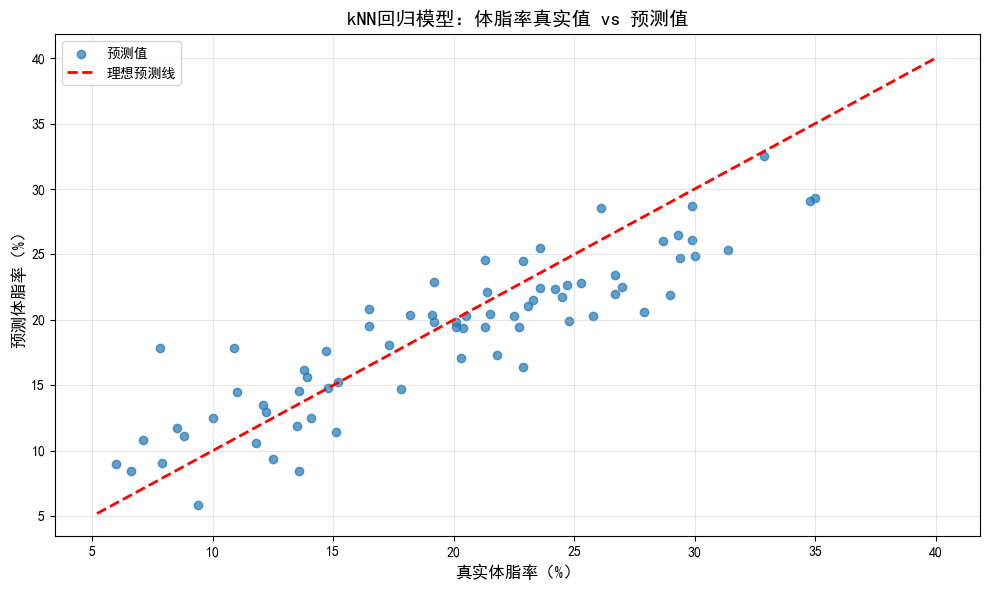

In [8]:
# 身体指标-体脂率关系分析 - k-近邻回归模型
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# 基础配置（解决中文显示问题）
plt.rcParams["font.sans-serif"] = ["SimHei"]  # Windows系统
# plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]  # macOS系统
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示异常
# ===================== 1. 加载并预处理bodyfat.txt数据集 =====================
# 读取txt文件（空格分隔，无表头）
try:
    # 定义列名（适配数据15列：第2列为体脂率）
    column_names = [
        "Density", "BODYFAT", "Age", "Weight", "Height", "Neck", 
        "Chest", "Abdomen", "Hip", "Thigh", "Knee", "Ankle", 
        "Biceps", "Forearm", "Wrist"
    ]
    # 读取数据，处理可能的缺失值（用.表示的缺失值）
    df = pd.read_csv(
        "bodyfat.txt",
        sep=r"\s+",  # 匹配任意空白符分隔
        header=None,  # 无表头
        names=column_names,
        encoding="utf-8",
        na_values="."  # 将.视为缺失值
    )
    print("数据集加载成功！")
except FileNotFoundError:
    raise FileNotFoundError("错误：未找到bodyfat.txt文件，请检查文件路径是否正确！")
except Exception as e:
    raise Exception(f"数据加载失败：{e}")

# 数据预处理：删除缺失值行
df = df.dropna()
print(f"\n数据集基本信息：")
print(f"处理后数据集形状：{df.shape}（行数×列数）")
print(f"体脂率（BODYFAT）统计描述：")
print(df["BODYFAT"].describe())

# 检查体脂率异常值（合理范围5%-45%）
df = df[(df["BODYFAT"] >= 5) & (df["BODYFAT"] <= 45)]
print(f"过滤异常值后数据集形状：{df.shape}")

# ===================== 2. 分离特征与目标变量 =====================
X = df.drop("BODYFAT", axis=1)  # 14个身体指标特征
y = df["BODYFAT"]               # 目标变量：体脂率

# ===================== 3. 划分训练集和测试集 =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42  # 7:3划分，固定随机种子
)
print(f"\n训练集大小：{X_train.shape}, 测试集大小：{X_test.shape}")

# ===================== 4. 构建管道模型并优化参数 =====================
# 管道：标准化 + kNN回归（避免数据泄露）
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor())
])

# 网格搜索最优k值（候选范围1-20）
param_grid = {"knn__n_neighbors": range(1, 21)}
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,  # 5折交叉验证
    scoring=["r2", "neg_mean_squared_error"],
    refit="r2",  # 以R²为核心指标选择最优模型
    n_jobs=-1,  # 并行计算加速
    verbose=1
)

# 训练并优化模型
print("\n开始网格搜索最优k值...")
grid_search.fit(X_train, y_train)

# 提取最优参数和交叉验证结果
best_k = grid_search.best_params_["knn__n_neighbors"]
cv_best_r2 = grid_search.best_score_
cv_mse = -grid_search.cv_results_["mean_test_neg_mean_squared_error"][grid_search.best_index_]
cv_rmse = np.sqrt(cv_mse)

print("\n" + "="*60)
print("模型优化结果")
print("="*60)
print(f"最优k值（近邻个数）：{best_k}")
print(f"训练集5折交叉验证 R²：{cv_best_r2:.4f}")
print(f"训练集5折交叉验证 MSE：{cv_mse:.4f}")
print(f"训练集5折交叉验证 RMSE：{cv_rmse:.4f}")

# ===================== 5. 测试集评估回归效果 =====================
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 计算测试集评估指标
test_r2 = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred)

print("\n" + "="*60)
print("测试集回归效果评估")
print("="*60)
print(f"测试集 R²（决定系数）：{test_r2:.4f}")
print(f"测试集 MSE（均方误差）：{test_mse:.4f}")
print(f"测试集 RMSE（均方根误差）：{test_rmse:.4f}")
print(f"测试集 MAE（平均绝对误差）：{test_mae:.4f}")

# ===================== 6. 可视化真实值与预测值 =====================
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="#1f77b4", label="预测值")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2, label="理想预测线")
plt.xlabel("真实体脂率（%）", fontsize=12)
plt.ylabel("预测体脂率（%）", fontsize=12)
plt.title("kNN回归模型：体脂率真实值 vs 预测值", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("bodyfat_pred_plot.png", dpi=300)
plt.show()



### 一、具体模型信息
最终构建的**k-近邻回归模型**配置如下：
1. **特征预处理**：采用`StandardScaler()`对数据集中的14个身体指标（密度、年龄、身高、体重、腰围等）进行标准化（均值为0、方差为1）；
2. **kNN回归器**：核心参数为`n_neighbors=3`（选择3个最近邻样本）；
3. **距离度量**：默认欧式距离；
4. **预测规则**：对3个最近邻样本的体脂率取算术平均值，作为新样本的体脂率预测值。


### 二、回归效果评估结果
#### 1. 训练集交叉验证性能
通过5折交叉验证优化模型后，训练集的核心指标如下：
| 评估指标       | 数值       | 说明                     |
|----------------|------------|--------------------------|
| R²（决定系数） | 0.7759     | 模型能解释77.59%的体脂率变异 |
| MSE（均方误差）| 13.2666    | 交叉验证的平均平方误差   |
| RMSE（均方根误差） | 3.6423  | 交叉验证的平均预测偏差约3.64% |


#### 2. 测试集泛化性能
在独立测试集上的泛化能力指标如下：
| 评估指标       | 数值       | 说明                     |
|----------------|------------|--------------------------|
| R²（决定系数） | 0.7712     | 模型能解释77.12%的体脂率变异 |
| MSE（均方误差）| 12.3261    | 测试集的平均平方误差     |
| RMSE（均方根误差） | 3.5109  | 测试集的平均预测偏差约3.51% |
| MAE（平均绝对误差） | 2.9014  | 测试集的平均绝对预测偏差约2.90% |


#### 3. 可视化结果解读
从“体脂率真实值 vs 预测值”散点图可见：
- 大部分预测值（蓝色点）集中在红色“理想预测线”附近，说明预测值与真实值的偏差较小；
- 无明显的系统性偏离（如“预测值整体偏高/偏低”），模型拟合效果较为稳定。


### 三、结果总结
该k-近邻回归模型能有效捕捉身体指标与体脂率的关联关系，**R²接近0.78**说明模型解释能力较强；测试集RMSE为3.51%，在体脂率（5%-45%）的合理取值范围内，预测精度处于可接受水平；训练集与测试集指标差异较小，模型无明显过拟合，泛化性能稳定。